## Task 1

In [1]:
import os
from pathlib import Path

# Define paths to your dataset folders
IMAGE_DIR = Path("data/DATA_CLEAN/images")
LABEL_DIR = Path("data/DATA_CLEAN/labels")

# Gather all file stems (filenames without their .jpg/.txt extensions)
image_extensions = ('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG')
image_stems = {f.stem for f in IMAGE_DIR.iterdir() if f.suffix in image_extensions}
label_stems = {f.stem for f in LABEL_DIR.iterdir() if f.suffix == '.txt'}

# Calculate counts
num_images = len(image_stems)
num_labels = len(label_stems)

# Find mismatches using set operations
images_without_labels = image_stems - label_stems
labels_without_images = label_stems - image_stems


print(f"Number of images:      {num_images}")
print(f"Number of label files: {num_labels}")


if len(images_without_labels) == 0 and len(labels_without_images) == 0:
    print("Match Verification: Perfect! Every image has a matching label file and vice versa.")
else:
    print("Match Verification: Mismatches found!")
    if images_without_labels:
        print(f"   {len(images_without_labels)} images are missing a .txt label file.")
        print(f"     Samples: {list(images_without_labels)[:5]}")
    if labels_without_images:
        print(f"   {len(labels_without_images)} label files are missing a corresponding image.")
        print(f"     Samples: {list(labels_without_images)[:5]}")

Number of images:      3327
Number of label files: 3327
Match Verification: Perfect! Every image has a matching label file and vice versa.


          Object Count
Class ID              
0                 3895

Total Unique Classes: 1
Total Labeled Objects: 3895


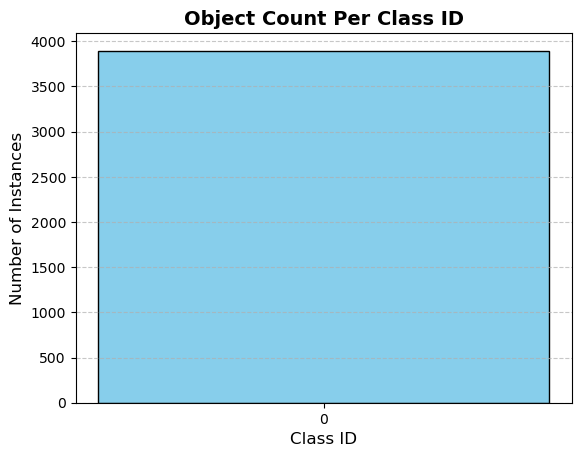

In [2]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

LABEL_DIR = Path("data/DATA_CLEAN/labels")

# Count class occurrences across all files
class_counts = Counter()

for label_file in LABEL_DIR.glob("*.txt"):
    with open(label_file, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if parts:  # Skip empty lines
                class_id = int(parts[0])  # First number is the class ID
                class_counts[class_id] += 1

# Convert to a sorted DataFrame for a clean table view
df_classes = pd.DataFrame.from_dict(class_counts, orient='index', columns=['Object Count'])
df_classes.index.name = 'Class ID'
df_classes = df_classes.sort_index()


print(df_classes)
print()
print(f"Total Unique Classes: {len(df_classes)}")
print(f"Total Labeled Objects: {df_classes['Object Count'].sum()}")

plt.bar(df_classes.index.astype(str), df_classes['Object Count'], color='skyblue', edgecolor='black')
plt.title('Object Count Per Class ID', fontsize=14, fontweight='bold')
plt.xlabel('Class ID', fontsize=12)
plt.ylabel('Number of Instances', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.savefig('class_distribution.png', bbox_inches='tight')

Class 0 is only class, which perfectly fits a single-object detector.

In [6]:
import cv2
import random
import pandas as pd
from pathlib import Path

IMAGE_DIR = Path("data/DATA_CLEAN/images")

# Gather all available image files
image_extensions = ('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG')
all_images = [f for f in IMAGE_DIR.iterdir() if f.suffix in image_extensions]

# Select exactly 100 random images (reproducible seed)
random.seed(42)
sampled_images = random.sample(all_images, min(100, len(all_images)))

# dimensions
widths = []
heights = []

for img_path in sampled_images:
    # cv2.imread is fast, but we can use a lightweight alternative or standard read
    img = cv2.imread(str(img_path))
    if img is not None:
        h, w, _ = img.shape
        widths.append(w)
        heights.append(h)

# Create a DataFrame to easily extract descriptive statistics
df_dims = pd.DataFrame({'Width': widths, 'Height': heights})

# summary statistics
stats = pd.DataFrame({
    'Min': df_dims.min(),
    'Max': df_dims.max(),
    'Mean': df_dims.mean()
})

print("Image Size Statistics (Sample Size: 100)")
print(stats.round(2))

Image Size Statistics (Sample Size: 100)
        Min   Max     Mean
Width   640  6000  2635.54
Height  640  4608  1997.18


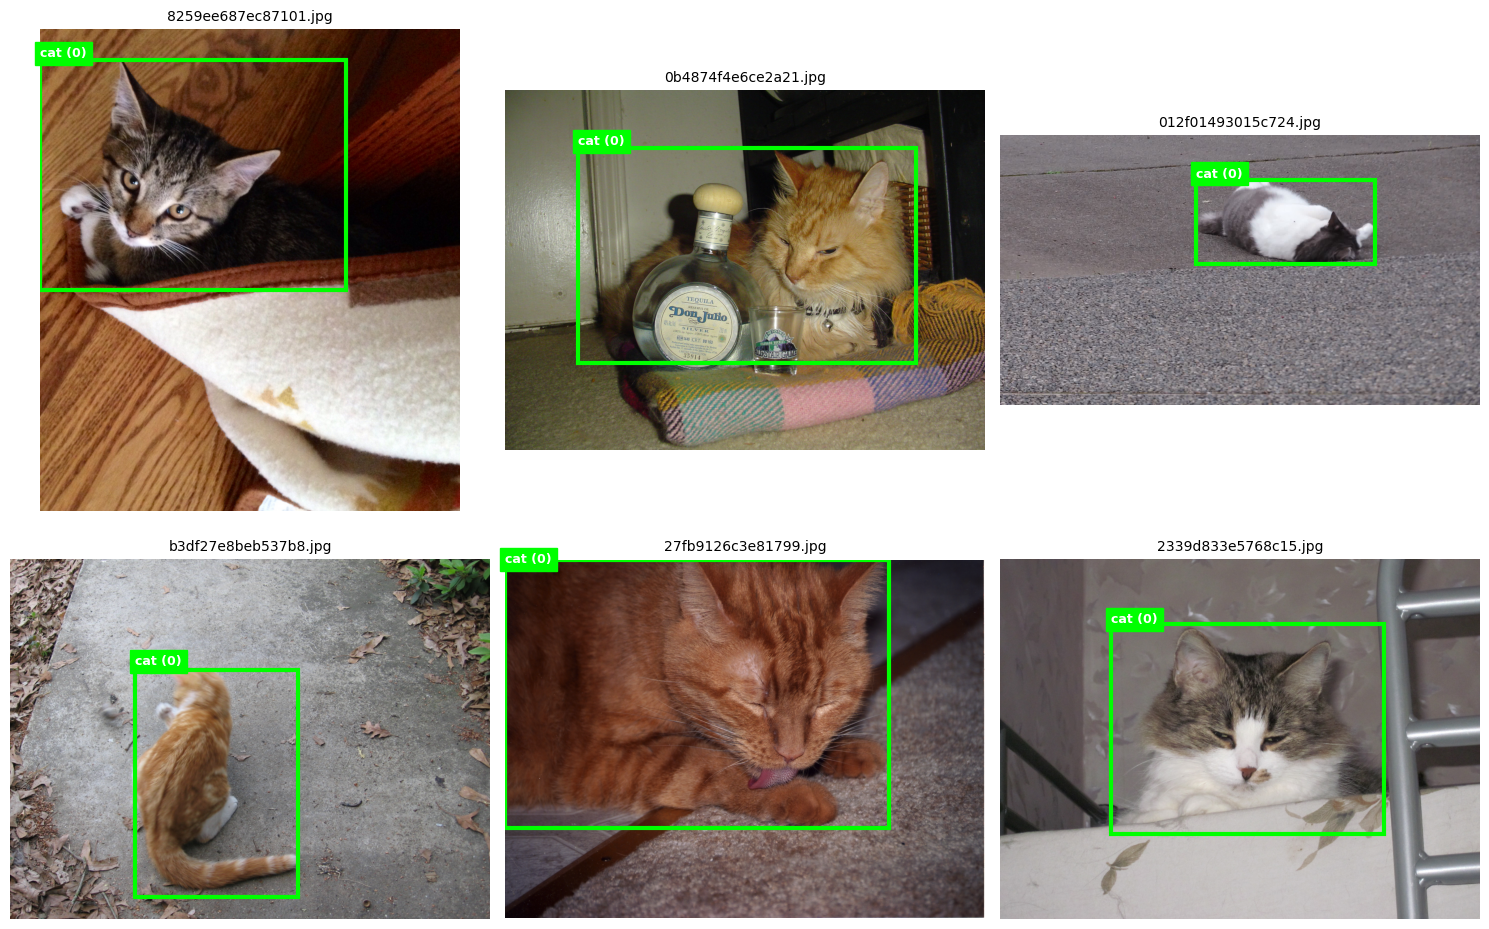

In [10]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from pathlib import Path

IMAGE_DIR = Path("data/DATA_CLEAN/images")
LABEL_DIR = Path("data/DATA_CLEAN/labels")

# Gather all available image files
image_extensions = ('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG')
all_images = [f for f in IMAGE_DIR.iterdir() if f.suffix in image_extensions]

# Pick 6 random images
random.seed(42)
selected_images = random.sample(all_images, 6)

# Create a 2x3 grid plot 
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, img_path in enumerate(selected_images):
    # Load image using PIL
    img = Image.open(img_path)
    w_img, h_img = img.size
    
    # Display the image on the current subplot axis
    ax = axes[i]
    ax.imshow(img)
    ax.set_title(img_path.name, fontsize=10)
    ax.axis('off')
    
    # Locate corresponding label file
    label_path = LABEL_DIR / f"{img_path.stem}.txt"
    
    if label_path.exists():
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if not parts:
                    continue
                
                class_id = parts[0]
                cx, cy, w, h = map(float, parts[1:5])
                
                # Denormalize coordinates to calculate the top-left corner
                xmin = (cx - w / 2) * w_img
                ymin = (cy - h / 2) * h_img
                box_width = w * w_img
                box_height = h * h_img
                
                # Create and add the Rectangle patch as specified in the hint
                rect = patches.Rectangle(
                    (xmin, ymin), box_width, box_height, 
                    linewidth=3, edgecolor='#00FF00', facecolor='none'
                )
                ax.add_patch(rect)
                
                # Add text label anchor overlay
                ax.text(xmin, max(ymin - 12, 15), f"cat ({class_id})", color='white', 
                        backgroundcolor='#00FF00', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## Task 2

In [11]:
import random

IMAGE_DIR = Path("data/DATA_CLEAN/images")

# Gather all file stems (filenames without their extension) to ensure pairs stay together
image_extensions = ('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG')
all_stems = sorted(list({f.stem for f in IMAGE_DIR.iterdir() if f.suffix in image_extensions}))

# Shuffle the list with the requested fixed seed
random.seed(42)
random.shuffle(all_stems)

# Calculate split boundaries for 70% / 15% / 15%
total_files = len(all_stems)
train_end = int(total_files * 0.70)
val_end = train_end + int(total_files * 0.15)

# Slice the shuffled list into subsets
train_stems = all_stems[:train_end]
val_stems = all_stems[train_end:val_end]
test_stems = all_stems[val_end:]

print(f"Total Dataset Size: {total_files}")
print(f"--- Roughly 70/15/15 Split ---")
print(f"Train Set Size:      {len(train_stems)} ({len(train_stems)/total_files:.1%})")
print(f"Validation Set Size:  {len(val_stems)} ({len(val_stems)/total_files:.1%})")
print(f"Test Set Size:        {len(test_stems)} ({len(test_stems)/total_files:.1%})")

Total Dataset Size: 3327
--- Roughly 70/15/15 Split ---
Train Set Size:      2328 (70.0%)
Validation Set Size:  499 (15.0%)
Test Set Size:        500 (15.0%)


In [12]:
# the directory where images are stored
IMAGE_DIR = Path("data/DATA_CLEAN/images")

# Function to write paths to a text file
def write_paths_file(stems, output_filename):
    with open(output_filename, 'w') as f:
        for stem in stems:
            # Check for standard extensions to ensure the exact file path is written
            img_path = IMAGE_DIR / f"{stem}.jpg"
            if not img_path.exists():
                img_path = IMAGE_DIR / f"{stem}.png"  # Fallback check
                
            # Write the relative path to the file
            f.write(f"{img_path}\n")
    print(f"Successfully created {output_filename} with {len(stems)} paths.")

# Execute the writing process for all three splits
write_paths_file(train_stems, "train.txt")
write_paths_file(val_stems, "val.txt")
write_paths_file(test_stems, "test.txt")

Successfully created train.txt with 2328 paths.
Successfully created val.txt with 499 paths.
Successfully created test.txt with 500 paths.


In [13]:
from pathlib import Path

# Define the YAML configuration content based on my exact dataset layout
yaml_content = """
path: ./          # Current working directory where train.txt, val.txt, test.txt sit
train: train.txt  # Path to the training split text file
val: val.txt      # Path to the validation split text file
test: test.txt    # Path to the test split text file

# Class mappings found during your distribution check
names:
  0: cat
"""

# Define the output path for the configuration file
yaml_path = Path("data.yaml")

# Write the string directly into the file
with open(yaml_path, "w") as f:
    f.write(yaml_content.strip())

print(f"Successfully created configuration file at: {yaml_path.resolve()}")
print("--- File Content ---")
print(yaml_content.strip())

Successfully created configuration file at: C:\Users\Hp Envy\Desktop\data.yaml
--- File Content ---
path: ./          # Current working directory where train.txt, val.txt, test.txt sit
train: train.txt  # Path to the training split text file
val: val.txt      # Path to the validation split text file
test: test.txt    # Path to the test split text file

# Class mappings found during your distribution check
names:
  0: cat
